In [1]:
import pandas as pd
df = pd.read_csv("/Users/yongyili/Desktop/train.csv")
documents = df["sms"].tolist()

In [2]:
import re

cleaned_docs = [re.sub(r'[^\w\s]', '', doc.lower()) for doc in documents]


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(cleaned_docs)


In [4]:
print(X.shape)             
print(vectorizer.get_feature_names_out())  

(5574, 9279)
['008704050406' '0089my' '0121' ... 'zouk' 'zyada' 'üll']


from sklearn.decomposition import TruncatedSVD
n_components = 10
svd = TruncatedSVD(n_components=5)  
X_reduced = svd.fit_transform(X)


In [6]:
from sklearn.decomposition import TruncatedSVD 
n_components = 10 
svd = TruncatedSVD(n_components=n_components)
X_reduced = svd.fit_transform(X)


In [7]:
X_approx = svd.inverse_transform(X_reduced)

In [8]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(X.toarray(), X_approx)
print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.00010125685317290465


In [9]:
from sklearn.metrics import mean_squared_error
X_dense = X.toarray()
mse = mean_squared_error(X_dense, X_approx)
explained = svd.explained_variance_ratio_.sum()

print("\nReconstruction MSE:", mse)
print("Explained Variance (information retained):", explained)


Reconstruction MSE: 0.00010125685317290465
Explained Variance (information retained): 0.05198399764865549


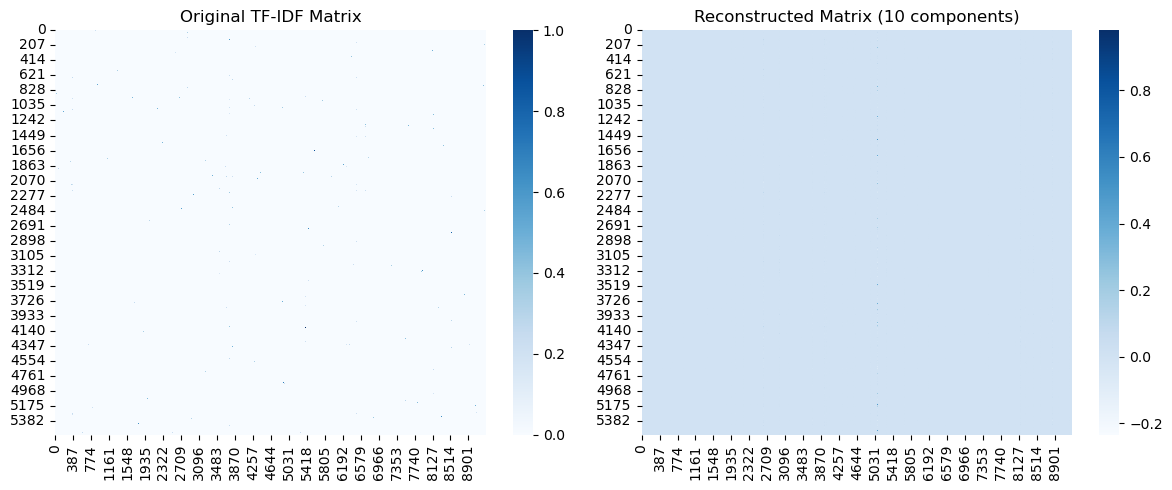

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
sns.heatmap(X_dense, cmap='Blues', annot=False)
plt.title("Original TF-IDF Matrix")

# Compressed
plt.subplot(1, 2, 2)
sns.heatmap(X_approx, cmap='Blues', annot=False)
plt.title(f"Reconstructed Matrix ({n_components} components)")

plt.tight_layout()
plt.show()